**Mallin tarkistus**
Uudelleen koukutus, lataus, tarkistus ja kuvaajan piirto

Ladataan dataa ja luodaan X_test uudelleen...
Ladataan malli ja piirretään kuvaaja...


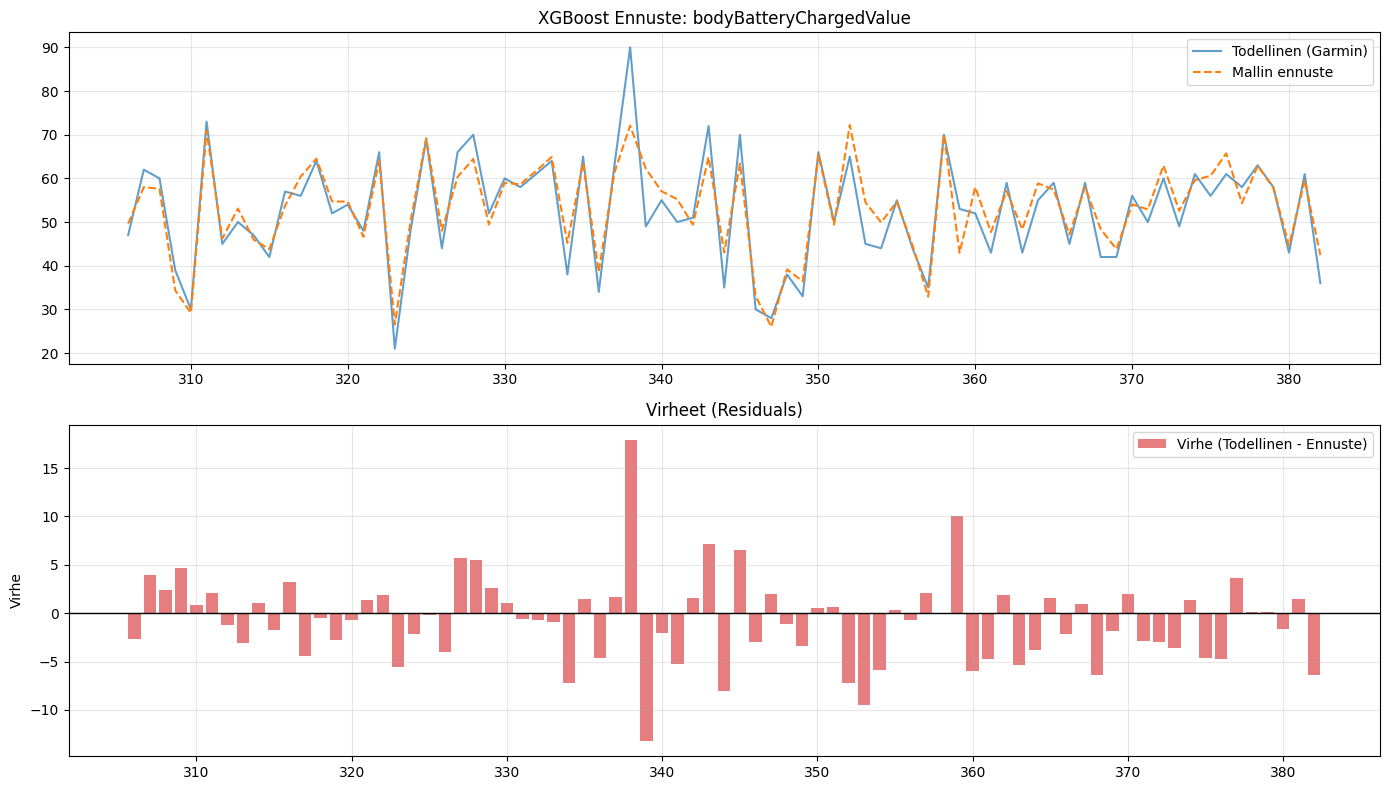

In [2]:
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# --- 1. DATAN LATAUS JA ESIKÄSITTELY (Kopioitu sinun koodistasi) ---
print("Ladataan dataa ja luodaan X_test uudelleen...")

try:
    df_summary = pd.read_csv("Health_AI/data/garmin_daily_summary.csv")
    df_sleep = pd.read_csv("Health_AI/data/garmin_sleep_data.csv")
    df_activities = pd.read_csv("Health_AI/data/garmin_activities.csv")
except FileNotFoundError:
    print("VIRHE: Tiedostoja ei löydy. Tarkista polut!")

# Päivämäärät
df_summary['date'] = pd.to_datetime(df_summary['date'])

# Feature Engineering: Poor Night Flag
if 'bodyBatteryDuringSleep' in df_summary.columns:
    df_summary['poor_night_flag'] = (df_summary['bodyBatteryDuringSleep'] < 45).astype(int)
else:
    df_summary['poor_night_flag'] = 0

if 'calendarDate' in df_sleep.columns:
    df_sleep['date'] = pd.to_datetime(df_sleep['calendarDate'])
elif 'date' in df_sleep.columns:
    df_sleep['date'] = pd.to_datetime(df_sleep['date'])

if 'startTimeLocal' in df_activities.columns:
     df_activities['date'] = pd.to_datetime(df_activities['startTimeLocal']).dt.date
     df_activities['date'] = pd.to_datetime(df_activities['date'])

# Aktiviteettien yhdistäminen
activity_aggs = df_activities.groupby('date').agg({
    'calories': 'sum',
    'duration': 'sum',
    'averageHR': 'mean'
}).rename(columns={'calories': 'workout_calories', 'duration': 'workout_duration_seconds', 'averageHR': 'workout_avg_hr'}).reset_index()

# Yhdistäminen (Merge)
df_merged = pd.merge(df_summary, df_sleep, on='date', how='left', suffixes=('', '_sleep'))
df_merged = pd.merge(df_merged, activity_aggs, on='date', how='left')

# Täytetään tyhjät
df_merged['workout_calories'] = df_merged['workout_calories'].fillna(0)
df_merged['workout_duration_seconds'] = df_merged['workout_duration_seconds'].fillna(0)

# Uniminuutit
if 'totalSleepSeconds' in df_merged.columns:
    df_merged['totalSleep_minutes'] = df_merged['totalSleepSeconds'] / 60
elif 'sleepingSeconds' in df_merged.columns:
    df_merged['totalSleep_minutes'] = df_merged['sleepingSeconds'] / 60
else:
    df_merged['totalSleep_minutes'] = 0

df_merged = df_merged.sort_values('date')

# Feature Engineering
df_merged['workout_calories_roll_7d'] = df_merged['workout_calories'].rolling(7, min_periods=1).mean()
lag_cols = ['bodyBatteryChargedValue', 'averageStressLevel', 'totalSteps', 'totalSleep_minutes']
for col in lag_cols:
    if col in df_merged.columns:
        df_merged[f'{col}_lag_1'] = df_merged[col].shift(1)

df_merged = df_merged.dropna(subset=['bodyBatteryChargedValue', 'bodyBatteryChargedValue_lag_1'])

# --- 2. MUUTTUJIEN VALINTA JA JAKO (Split) ---
target = 'bodyBatteryChargedValue'
drop_cols = ['date', 'bodyBatteryChargedValue', 'bodyBatteryDrainedValue', 'calendarDate', 'calendarDate_sleep']

X = df_merged.drop(columns=[c for c in drop_cols if c in df_merged.columns])
X = X.select_dtypes(include=['number'])
y = df_merged[target]

# TÄRKEÄÄ: Sama random_state ja shuffle=False kuin koulutuksessa!
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)

# --- 3. LATAA MALLI JA PIIRRÄ KUVAAJA ---
print("Ladataan malli ja piirretään kuvaaja...")

try:
    model = joblib.load("Health_AI/models/xgb_model.pkl") # Lataa tallennettu malli
    
    # Ennusteet
    y_pred = model.predict(X_test)

    # DataFrame tuloksille
    df_results = pd.DataFrame({
        'Todellinen': y_test,
        'Ennuste': y_pred
    }, index=y_test.index) # Indeksi säilyy

    df_results['Virhe'] = df_results['Todellinen'] - df_results['Ennuste']

    # Visualisointi
    plt.figure(figsize=(14, 8))

    # Ylempi: Ennuste vs Todellinen
    plt.subplot(2, 1, 1)
    plt.plot(df_results.index, df_results['Todellinen'], label='Todellinen (Garmin)', color='tab:blue', alpha=0.7)
    plt.plot(df_results.index, df_results['Ennuste'], label='Mallin ennuste', color='tab:orange', linestyle='--')
    plt.title(f'XGBoost Ennuste: {target}')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Alempi: Virheet
    plt.subplot(2, 1, 2)
    plt.bar(df_results.index, df_results['Virhe'], color='tab:red', alpha=0.6, label='Virhe (Todellinen - Ennuste)')
    plt.axhline(0, color='black', linewidth=1)
    plt.title('Virheet (Residuals)')
    plt.ylabel('Virhe')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

except FileNotFoundError:
    print("VIRHE: Mallitiedostoa 'Health_AI/models/xgb_model.pkl' ei löydy. Aja koulutus ensin!")

--- TOP 10 VAIKUTTAVIMMAT TEKIJÄT ---
                       Feature  Importance
72             poor_night_flag    0.197827
55     bodyBatteryHighestValue    0.189942
58      bodyBatteryDuringSleep    0.127291
44            stressPercentage    0.075015
37          restStressDuration    0.050050
45        restStressPercentage    0.040893
59       bodyBatteryAtWakeTime    0.034390
36              stressDuration    0.028488
57  bodyBatteryMostRecentValue    0.019034
48         lowStressPercentage    0.016146


C:\Users\samih\AppData\Local\Temp\ipykernel_21904\2546784271.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=top_10, palette='viridis')


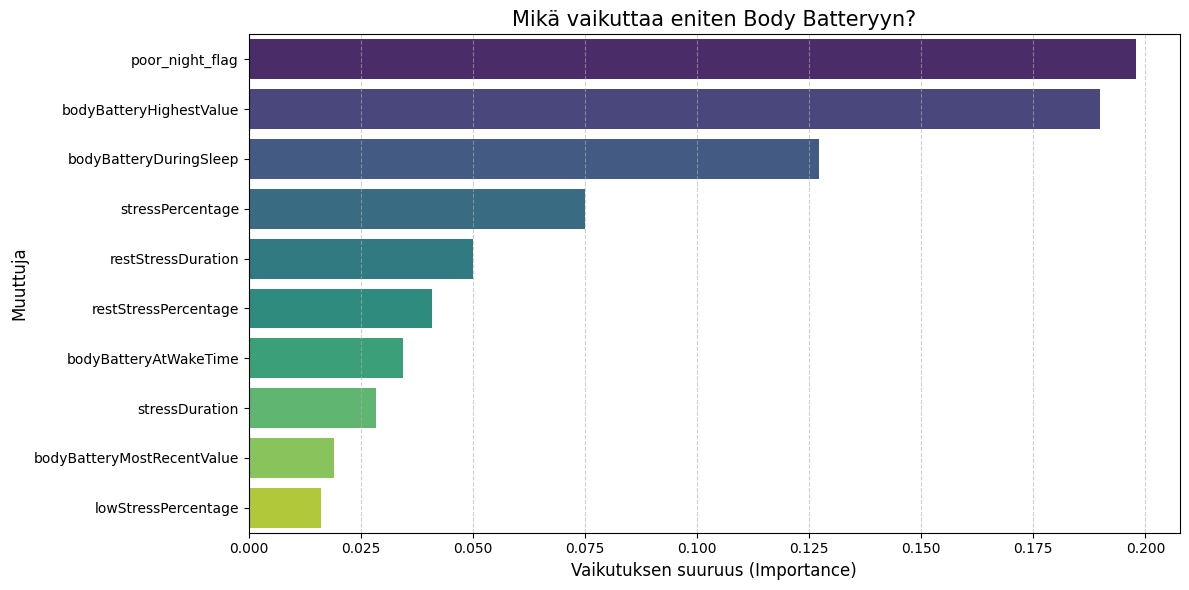

In [3]:
import seaborn as sns

# Tarkistetaan, että malli ja data ovat muistissa
if 'model' in locals() and 'X_test' in locals():
    
    # 1. Luodaan DataFrame tärkeyksistä
    importance_df = pd.DataFrame({
        'Feature': X_test.columns,
        'Importance': model.feature_importances_
    })

    # 2. Järjestetään suuruusjärjestykseen ja otetaan Top 10
    top_10 = importance_df.sort_values(by='Importance', ascending=False).head(10)

    # Tulostetaan arvot tekstinä
    print("--- TOP 10 VAIKUTTAVIMMAT TEKIJÄT ---")
    print(top_10)

    # 3. Piirretään vaakasuuntainen pylväskaavio
    plt.figure(figsize=(12, 6))
    sns.barplot(x='Importance', y='Feature', data=top_10, palette='viridis')
    
    plt.title('Mikä vaikuttaa eniten Body Batteryyn?', fontsize=15)
    plt.xlabel('Vaikutuksen suuruus (Importance)', fontsize=12)
    plt.ylabel('Muuttuja', fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=0.6)
    
    plt.tight_layout()
    plt.show()

else:
    print("VIRHE: 'model' tai 'X_test' puuttuu. Aja aiemmat koodit ensin!")

--- SHAP Waterfall Analyysi ---
Tarkastellaan testisetin ensimmäistä havaintoa: 306


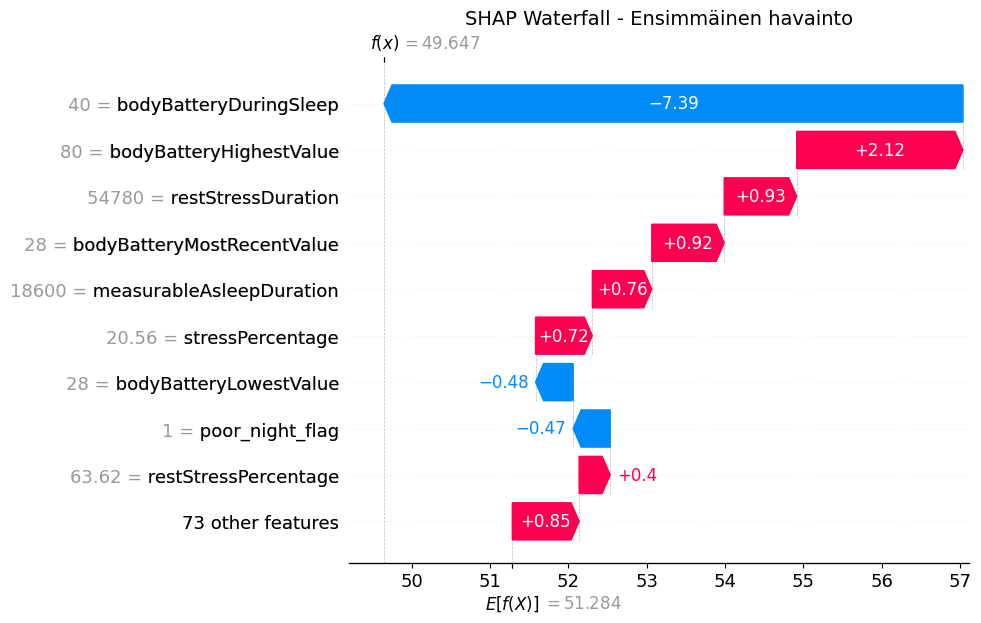

In [4]:
import shap
# plt is already imported as matplotlib.pyplot

print("--- SHAP Waterfall Analyysi ---")

# Varmistetaan että malli on olemassa
if 'model' in locals() and 'X_test' in locals():
    # Alustetaan Explainer
    explainer = shap.Explainer(model)
    shap_values = explainer(X_test)
    
    # Piirretään vesiputouskaavio ensimmäiselle havainnolle testisetissä
    # Tämä näyttää miten eri muuttujat vaikuttivat juuri tämän havainnon ennusteeseen
    print(f"Tarkastellaan testisetin ensimmäistä havaintoa: {X_test.index[0]}")
    
    plt.figure() # Uusi kuva
    shap.plots.waterfall(shap_values[0], show=False)
    plt.title(f'SHAP Waterfall - Ensimmäinen havainto', fontsize=14)
    plt.show()
else:
    print("Malli tai data puuttuu.")